In [1]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
import lal
import lalsimulation as lalsim
from ripplegw.waveforms.IMRPhenomXPHM import XLALSimIMRPhenomHMGethlmModes
from ripplegw.constants import MSUN, MTSUN, PI

/tmp/ipykernel_1052911/1133107445.py:6: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
m1 = 36.0
m2 = 29.0
m1_SI = m1 * MSUN
m2_SI = m2 * MSUN

chi1x = 0.1
chi1y = 0.2
chi1z = 0.3
chi2x = 0.3
chi2y = 0.2
chi2z = 0.1

modes = jnp.array([[2,1],[2,2],[3,2],[3,3],[4,4]])
extra_params = {"ModeArray": modes}


minimum_frequency = 20
maximum_frequency = 1024
duration = 8.
df = 1/duration
reference_frequency = 50

f = np.arange(minimum_frequency, maximum_frequency, df)

In [ ]:
hlms_ripple = XLALSimIMRPhenomHMGethlmModes(
    f,
    m1_SI,
    m2_SI,
    chi1x,
    chi1y,
    chi1z,
    chi2x,
    chi2y,
    chi2z,
    0.0,
    df,
    reference_frequency,
    extra_params,
)

In [4]:
lalparams = lal.CreateDict()

ModeArray = lalsim.SimInspiralCreateModeArray()

lalsim.SimInspiralModeArrayActivateMode(ModeArray, 2, 1)
lalsim.SimInspiralModeArrayActivateMode(ModeArray, 2, 2)

lalsim.SimInspiralModeArrayActivateMode(ModeArray, 3, 2)
lalsim.SimInspiralModeArrayActivateMode(ModeArray, 3, 3)

#lalsim.SimInspiralModeArrayActivateMode(ModeArray, 4, 3)
lalsim.SimInspiralModeArrayActivateMode(ModeArray, 4, 4)

lalsim.SimInspiralWaveformParamsInsertModeArray(lalparams, ModeArray)

f_seq = lal.CreateREAL8Sequence(len(f))
f_seq.data = f
hlms_lal_out = lalsim.SimIMRPhenomHMGethlmModes(
    f_seq,
    m1_SI,
    m2_SI,
    chi1x,
    chi1y,
    chi1z,
    chi2x,
    chi2y,
    chi2z,
    0.0,
    df,
    reference_frequency,
    lalparams
)

In [5]:
# Iterate through the linked list
hlm = hlms_lal_out
hlms_lal = np.zeros_like(hlms_ripple)
n = 0
while hlm is not None:
    ell = hlm.l
    m = hlm.m
    data = hlm.mode.data.data  # Complex frequency series data
    hlms_lal[n] += data
    print(f"Mode ({ell}, {m})")
    
    # Move to next mode in the linked list
    hlm = hlm.next
    n += 1

hlms_lal = hlms_lal[::-1]

Mode (4, 4)
Mode (3, 3)
Mode (3, 2)
Mode (2, 2)
Mode (2, 1)


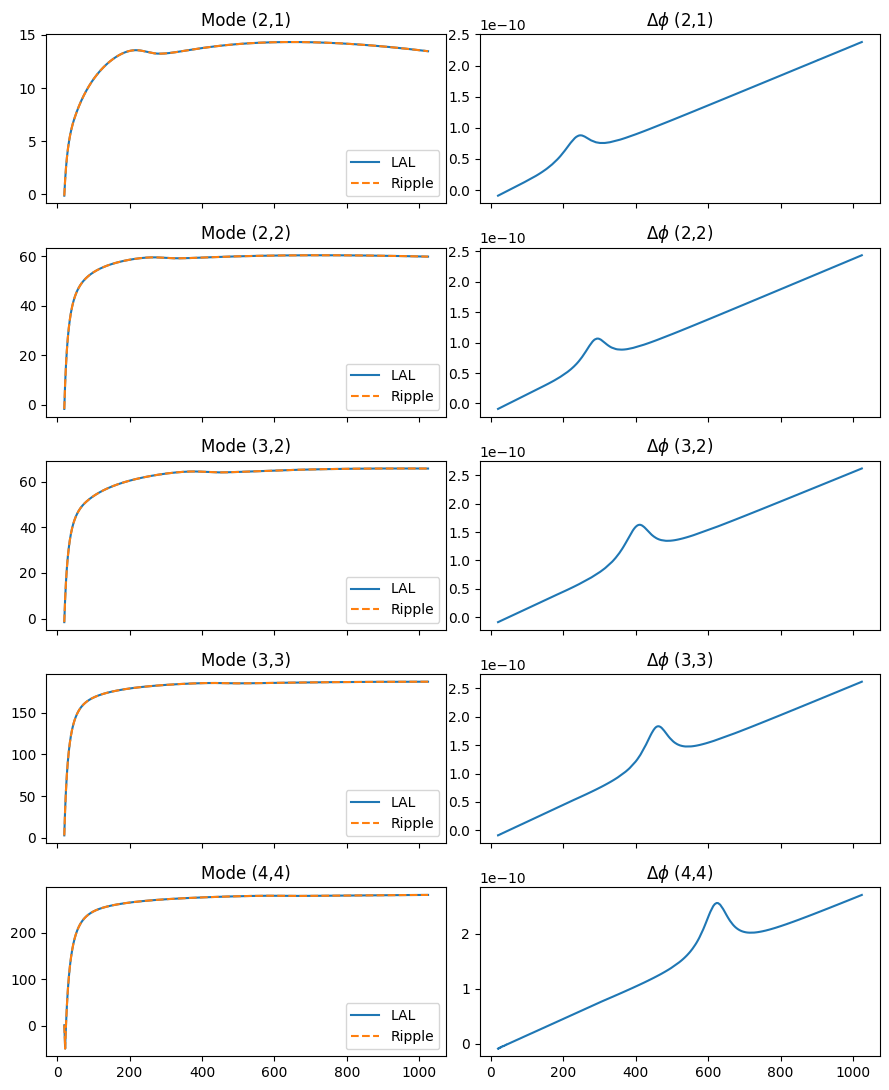

In [6]:
fig, ax = plt.subplots(5, 2, figsize = (9, 11), sharex = True)
for i, lm_pair in enumerate(modes):
    phase_ripple = jnp.unwrap(jnp.angle(hlms_ripple[i]))
    phase_lal = jnp.unwrap(jnp.angle(hlms_lal[i]))
    ax[i,0].plot(f, phase_lal, label = "LAL")
    ax[i,0].plot(f, phase_ripple, linestyle = "--", label = "Ripple")
    ax[i,0].set_title(f"Mode ({lm_pair[0]},{lm_pair[1]})")
    ax[i,0].legend()

    dphase = phase_ripple - phase_lal
    ax[i,1].plot(f, dphase)
    ax[i,1].set_title(r"$\Delta \phi$" + f" ({lm_pair[0]},{lm_pair[1]})")

fig.tight_layout()
plt.show()

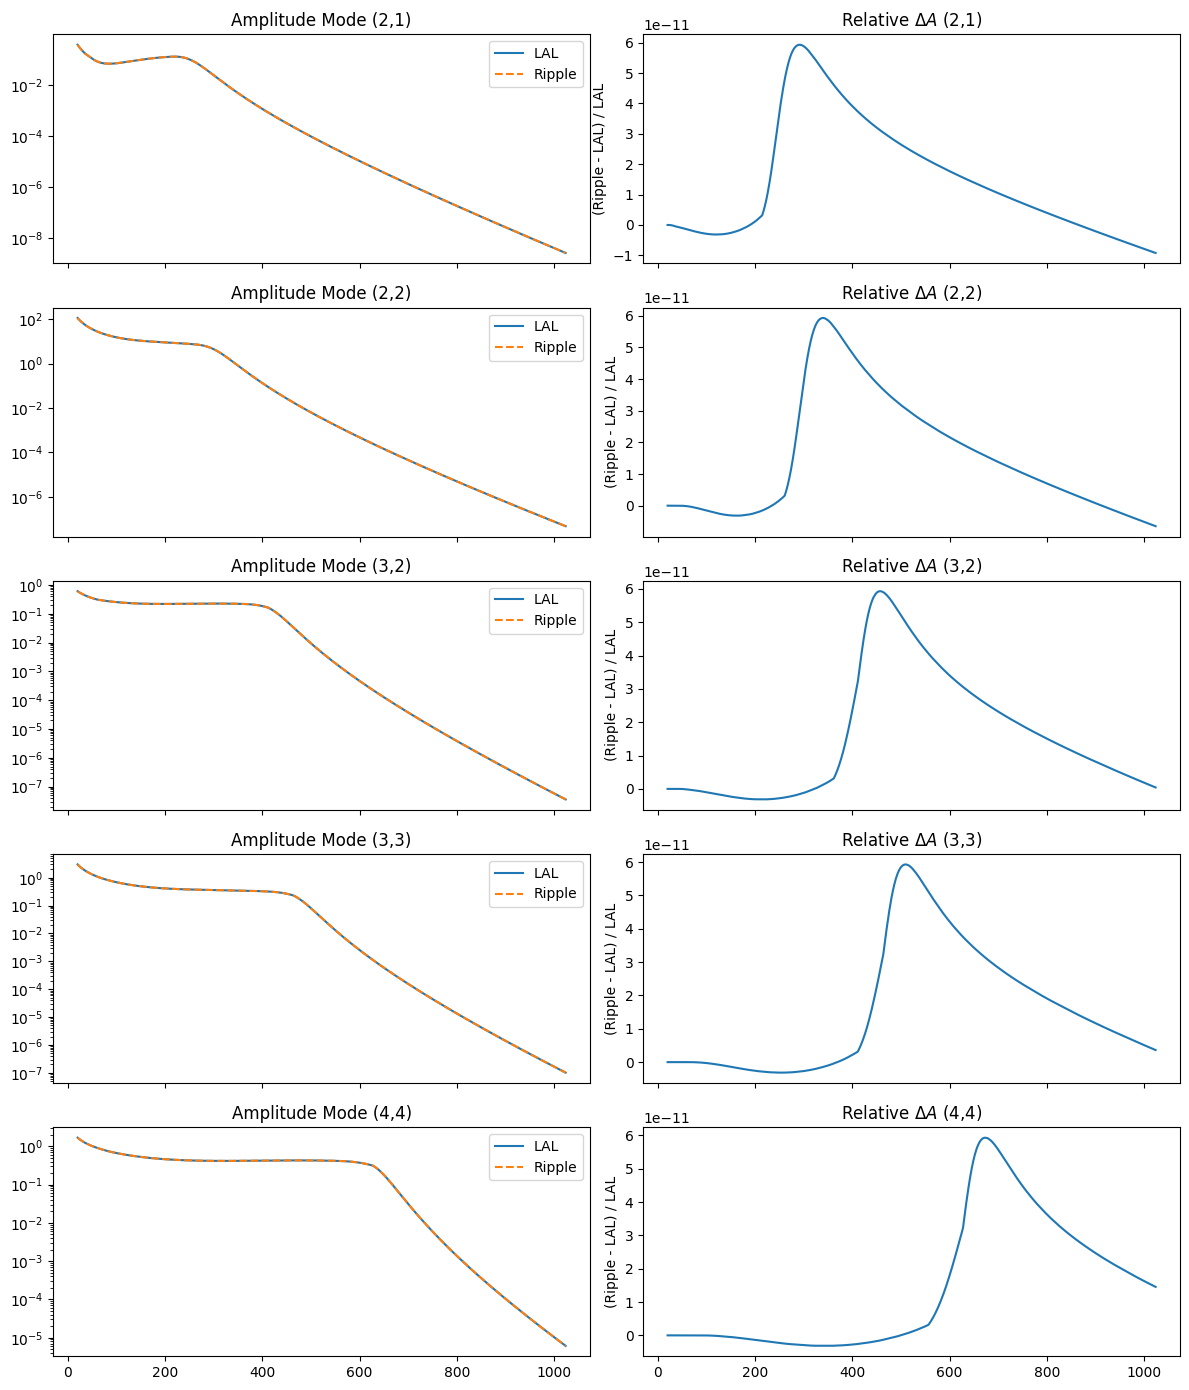

In [12]:
# Compare amplitudes directly
fig, ax = plt.subplots(5, 2, figsize = (12, 14), sharex = True)
for i, lm_pair in enumerate(modes):
    amp_ripple = jnp.abs(hlms_ripple[i])
    amp_lal = jnp.abs(hlms_lal[i])
    
    ax[i,0].plot(f, amp_lal, label = "LAL")
    ax[i,0].plot(f, amp_ripple, linestyle = "--", label = "Ripple")
    ax[i,0].set_title(f"Amplitude Mode ({lm_pair[0]},{lm_pair[1]})")
    ax[i,0].legend()
    ax[i,0].set_yscale('log')

    # Relative difference
    rel_diff = (amp_ripple - amp_lal) / amp_lal
    ax[i,1].plot(f, rel_diff)
    ax[i,1].set_title(r"Relative $\Delta A$" + f" ({lm_pair[0]},{lm_pair[1]})")
    ax[i,1].set_ylabel("(Ripple - LAL) / LAL")

fig.tight_layout()
plt.show()

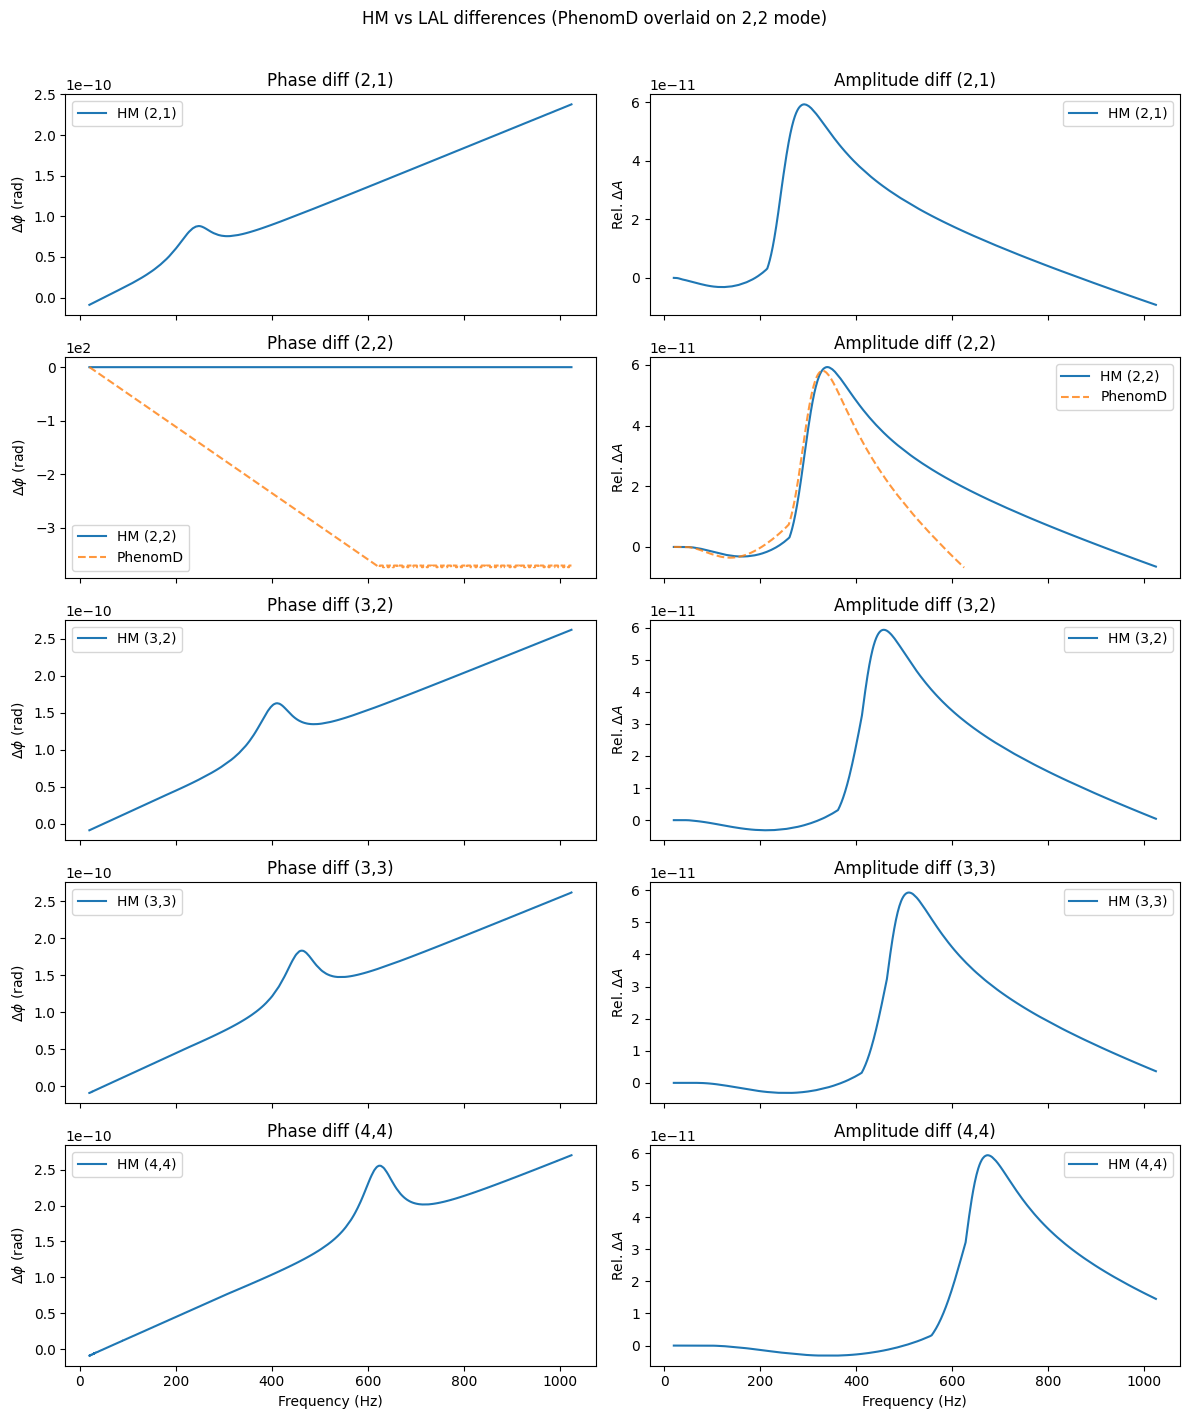


Maximum errors:
  PhenomD phase: 3.74e+02 rad
  PhenomD amp:   5.81e-11
  HM (2,1) phase: 2.38e-10 rad, amp: 5.93e-11
  HM (2,2) phase: 2.44e-10 rad, amp: 5.93e-11
  HM (3,2) phase: 2.62e-10 rad, amp: 5.93e-11
  HM (3,3) phase: 2.62e-10 rad, amp: 5.93e-11
  HM (4,4) phase: 2.70e-10 rad, amp: 5.93e-11


In [33]:
# Compare HM vs LAL, with PhenomD overlaid on the (2,2) mode
import importlib
import ripplegw.waveforms.IMRPhenomD as IMRPhenomD_module
importlib.reload(IMRPhenomD_module)
from ripplegw.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc
from ripplegw import ms_to_Mc_eta

# Generate PhenomD from Ripple (using aligned spins only)
Mc, eta = ms_to_Mc_eta((m1, m2))
theta_phenomD = jnp.array([Mc, eta, chi1z, chi2z, 1000.0, 0.0, 0.0])  # aligned spin params
hp_ripple_D, hc_ripple_D = gen_IMRPhenomD_hphc(f, theta_phenomD, reference_frequency)

# Generate PhenomD from LAL using SimInspiralFD
distance_SI = 1000.0 * 1e6 * lal.PC_SI
hp_lal_D_series, hc_lal_D_series = lalsim.SimInspiralFD(
    m1_SI,
    m2_SI,
    0.0, 0.0, chi1z,  # S1
    0.0, 0.0, chi2z,  # S2
    distance_SI,
    0.0,  # inclination (face-on)
    0.0,  # phi_ref
    0.0,  # longAscNodes
    0.0,  # eccentricity
    0.0,  # meanPerAno
    df,
    minimum_frequency,
    maximum_frequency,
    reference_frequency,
    lal.CreateDict(),
    lalsim.IMRPhenomD
)

# Extract PhenomD LAL data - use frequency indices directly
# LAL starts from f0 = hp_lal_D_series.f0, with spacing deltaF
f0_lal = hp_lal_D_series.f0
df_lal = hp_lal_D_series.deltaF
n_lal = len(hp_lal_D_series.data.data)
f_lal_full = f0_lal + np.arange(n_lal) * df_lal

# Find indices matching our frequency array
idx_start = int(round((minimum_frequency - f0_lal) / df_lal))
idx_end = idx_start + len(f)
hp_lal_D = hp_lal_D_series.data.data[idx_start:idx_end]
hc_lal_D = hc_lal_D_series.data.data[idx_start:idx_end]

# Compute PhenomD differences 
phase_ripple_D = jnp.unwrap(jnp.angle(hp_ripple_D))
phase_lal_D = jnp.unwrap(jnp.angle(hp_lal_D))
dphase_D = phase_ripple_D - phase_lal_D

amp_ripple_D = jnp.abs(hp_ripple_D)
amp_lal_D = jnp.abs(hp_lal_D)
rel_amp_D = (amp_ripple_D - amp_lal_D) / amp_lal_D

# Create comparison plot
fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex=True)

for i, lm_pair in enumerate(modes):
    l, m_mode = int(lm_pair[0]), int(lm_pair[1])
    
    # Phase comparison
    phase_ripple_hm = jnp.unwrap(jnp.angle(hlms_ripple[i]))
    phase_lal_hm = jnp.unwrap(jnp.angle(hlms_lal[i]))
    dphase_hm = phase_ripple_hm - phase_lal_hm
    
    axes[i, 0].plot(f, dphase_hm, label=f"HM ({l},{m_mode})", color='C0')
    
    # Overlay PhenomD on (2,2) mode
    if l == 2 and m_mode == 2:
        axes[i, 0].plot(f, dphase_D, label="PhenomD", color='C1', linestyle='--', alpha=0.8)
    
    axes[i, 0].set_ylabel(r"$\Delta \phi$ (rad)")
    axes[i, 0].set_title(f"Phase diff ({l},{m_mode})")
    axes[i, 0].legend()
    axes[i, 0].ticklabel_format(axis='y', style='scientific', scilimits=(-2,2))
    
    # Amplitude comparison
    amp_ripple_hm = jnp.abs(hlms_ripple[i])
    amp_lal_hm = jnp.abs(hlms_lal[i])
    rel_amp_hm = (amp_ripple_hm - amp_lal_hm) / amp_lal_hm
    
    axes[i, 1].plot(f, rel_amp_hm, label=f"HM ({l},{m_mode})", color='C0')
    
    # Overlay PhenomD on (2,2) mode
    if l == 2 and m_mode == 2:
        axes[i, 1].plot(f, rel_amp_D, label="PhenomD", color='C1', linestyle='--', alpha=0.8)
    
    axes[i, 1].set_ylabel(r"Rel. $\Delta A$")
    axes[i, 1].set_title(f"Amplitude diff ({l},{m_mode})")
    axes[i, 1].legend()
    axes[i, 1].ticklabel_format(axis='y', style='scientific', scilimits=(-2,2))

axes[-1, 0].set_xlabel("Frequency (Hz)")
axes[-1, 1].set_xlabel("Frequency (Hz)")
fig.suptitle("HM vs LAL differences (PhenomD overlaid on 2,2 mode)", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

# Print max errors
print("\nMaximum errors:")
# Handle any NaN in PhenomD
dphase_D_valid = jnp.where(jnp.isfinite(dphase_D), dphase_D, 0.0)
rel_amp_D_valid = jnp.where(jnp.isfinite(rel_amp_D), rel_amp_D, 0.0)
print(f"  PhenomD phase: {jnp.max(jnp.abs(dphase_D_valid)):.2e} rad")
print(f"  PhenomD amp:   {jnp.max(jnp.abs(rel_amp_D_valid)):.2e}")
for i, lm_pair in enumerate(modes):
    phase_ripple_hm = jnp.unwrap(jnp.angle(hlms_ripple[i]))
    phase_lal_hm = jnp.unwrap(jnp.angle(hlms_lal[i]))
    dphase_hm = phase_ripple_hm - phase_lal_hm
    amp_ripple_hm = jnp.abs(hlms_ripple[i])
    amp_lal_hm = jnp.abs(hlms_lal[i])
    rel_amp_hm = (amp_ripple_hm - amp_lal_hm) / amp_lal_hm
    print(f"  HM ({lm_pair[0]},{lm_pair[1]}) phase: {jnp.max(jnp.abs(dphase_hm)):.2e} rad, amp: {jnp.max(jnp.abs(rel_amp_hm)):.2e}")